In [1]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from GNN_model.GNN import *
from function_libraries.generation_graph import parallel_gen_graph
from function_libraries.tracking import tracking_main
from matplotlib.lines import Line2D
import pandas as pd

c:\Users\imagi\anaconda3\envs\CML_GNN\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
number_of_color = 3
train_data = parallel_gen_graph(num_graph = 10,
                                number_of_color = number_of_color,
                                number_initial_liposome = 8,
                                number_merging_liposome = 2,
                                merging_distance_thres = 1.5,
                                distance_thres = 60,
                                percentage_blinking = 4,
                                noise_percentage = 3,
                                number_of_weak_FI = 1,
                                blinking = 6, 
                                initial_t = 0,
                                end_t = 2500,
                                random_time_interval = 200,
                                concentration = 20,
                                number_of_neighboring_liposome = 0,
                                merging_GT_strategy = "exact",
                                deterministic = True,
                                combinatorial = True,
                                number_of_core = 5) 

Graph generation: 100%|██████████| 10/10 [00:00<00:00, 9972.19it/s]


<div style="color:gray">
    
- __parallel_gen_graph__: generate simulated input graph that can be used for training and estimation. parallel_gen_graph function has the following variables:<br>
- __num_graph__: the number of simulated graph generated.<br>
- __number_of_color__: the number of available color for the vertex information. number_of_color = 1 mean the vertex has single color information.<br>
![merging_strategy](assets/initial_liposome.png)<br>
- __number_initial_liposome__: the number of ground truth particle trajectories appear in the graph.<br>
- __number_merging_liposome__: the number of ground truth particle trajectories that merge with other particle. If number_initial_liposome = 5 and
number_merging_liposome = 2, there will be 7 ground truth trajectories and 2 merging event.<br>
- __merging_distance_thres__: if two vertices are approached within merging_distance_thres, the two vertices will become a single vertex.<br>
- __distance_thres__: the maximum edge distance of ground truth trajectory.<br>
- __percentage_blinking__: the probability (max = 100) of blinking of ground truth trajectories.<br>
- __noise_percentage__: the relative percentage of false-positive noise vertex in every frame.<br>
- __number_of_weak_Fl__: the number of weak intensity particle trajectorie. In experimental situation, some of particles' intensities are in the threshold range of the detection limit. Therefore, exhibit frequently blinking particle emergence. The model distingush such frequently blinking vertex and does not connect the edges.<br>
- __blinking:__ the maximum number of continuos disappearing of ground truth particle trajectory.<br>
- __initial_t__: the starting time of the graph.<br>
- __end_t__: the ending time of the graph.<br>
- __random_time_interval__: the time interval of the graph.<br>
- __number_of_neighboring_liposome__: the percentage of false-positive particle relative to ground truth vertex (particles) appearing near the ground 
truth vertex.<br>
- __merging_GT_strategy__: the graph construction method. "exact": the merged particles are connected by two vertex through two edges. "jumping": there is no merging, but disappearing of particle.<br>
![merging_strategy](assets/merging_strategy.png).<br>
- __deterministic__: if deterministic == True, apply the above parameters exactly. If deterministic == False, [number_of_neighboring_liposome,noise_percentage, percentage_blinking, number_of_weak_FI] are randomly selected from the lower value of the above setting. <br>
- __combinatorial__: if combinatorial == Ture, simulate the particle in the presence of combinatorial color mixture for the single particle. If combinatorial == False, single particles can only have a single color. <br>
- __number_of_core__: the number of CPU cores for the sample generation.<br>

In [3]:
print("data set 0:", train_data[0])
print("node information:",train_data[0][0].x[3])
print("edge information:",train_data[0][0].edge_index[:,3])
print("ground truth connectivity:",train_data[0][0].y[3])
print("neighbor edges:",train_data[0][0].neighbor_edges[:,3])
print("edge correlation",train_data[0][0].edge_corr[3])


data set 0: (Data(x=[1889, 9], edge_index=[2, 54697], y=[54697], neighbor_edges=[2, 8146], edge_corr=[54697, 4]), array([[8.000e+00, 5.000e+00, 1.556e+03],
       [9.000e+00, 1.000e+00, 1.583e+03]]))
node information: tensor([1.4807e+03, 6.7204e+02, 1.3920e+03, 3.5868e+01, 5.0986e-01, 4.0658e+01,
        2.0000e+00, 3.0000e+00, 0.0000e+00])
edge information: tensor([0, 4])
ground truth connectivity: tensor(0)
neighbor edges: tensor([1308,    1])
edge correlation tensor([0.5279, 5.0000, 0.9993, 0.9991])


- Now we made 10 dataset and the first one is shown as above.<br>
- x is a node of the graph. [x,y, time, intensity, intensity, intensity, the earlier ground truth node index connected to the current node index, current node index, the trajectory index]<br>
- edge_index is the connectivity of node index. [the earlier ground truth node index connected to the current node index, current node index]<br>
- y is the ground truth edge connectivity. [0 = false, 1 = true]<br>
- neighbor_edges is the neighboring node connectivity with in the same frame. [the index of the current node, the index of neighboring node]<br>
- edge_corr is the correlations of teporally adjacent nodes. [distance, temporal difference, intensity correlation, product correlation]<br>
- The remainings are ground truth merging particle index and time [particle index, particle index, time]<br>


In [4]:
data_interest = train_data[0][0].clone()
GT_merging = train_data[0][0].clone()
True_positive = 0
False_positive = 0
False_negative = 0
True_negative = 0
total_loss = 0
weight = 2
thres = 0
device = "cuda"  #or "cpu"
GT_vertex = data_interest.x.clone()
data_interest.x = data_interest.x[:,0:(3+number_of_color)]
model_name = "model_weights/" + str(number_of_color) + "color.pt"
data = data_interest.to(device)

with torch.no_grad():
    model = torch.load(model_name,map_location=torch.device(device), weights_only=False) 
    pred = model(data)
True_positive += ((pred > thres) & (data.y ==1)).sum().item()
True_negative += ((pred < thres) & (data.y ==0)).sum().item()
False_negative += ((pred < thres) & (data.y==1)).sum().item()
False_positive += ((pred > thres) & (data.y==0)).sum().item()

acc = (True_positive/(True_positive + False_positive + False_negative+1e-5))  
print(data_interest)
print(data_interest.y.sum())
print("True_positive: ", True_positive)
print("True_negative: ", True_negative)
print("False_positive: ", False_positive)
print("False_negative: ", False_negative)
print("accuracy: ", acc)    
vertex = data_interest.x.cpu().numpy()
vertex[:,3:3+number_of_color] = vertex[:,3:3+number_of_color] * 10
edges_original = data_interest.edge_index.cpu().numpy()
edges_original = np.vstack((edges_original, pred.cpu().numpy()))
edges_original = edges_original.T
max_x = vertex[:,0].max()
min_x = vertex[:,0].min()
max_y = vertex[:,1].max()
min_y = vertex[:,1].min()
max_t = vertex[:,2].max()
min_t = vertex[:,2].min()       
intensity_threshold = vertex[:,3:3 + number_of_color].min()
actual_min_intensity  = intensity_threshold


Data(x=[1889, 6], edge_index=[2, 54697], y=[54697], neighbor_edges=[2, 8146], edge_corr=[54697, 4])
tensor(1309, device='cuda:0')
True_positive:  1303
True_negative:  53384
False_positive:  4
False_negative:  6
accuracy:  0.9923838462118519


The inferred connectivity graph shows the correctness.

Note that the accracy is define as True_positive/(True_positive + False_positive + False_negative) since True_negative is usually large number.

(1309, 2)


Text(0.5, 1.0, 'Inferred connectivity')

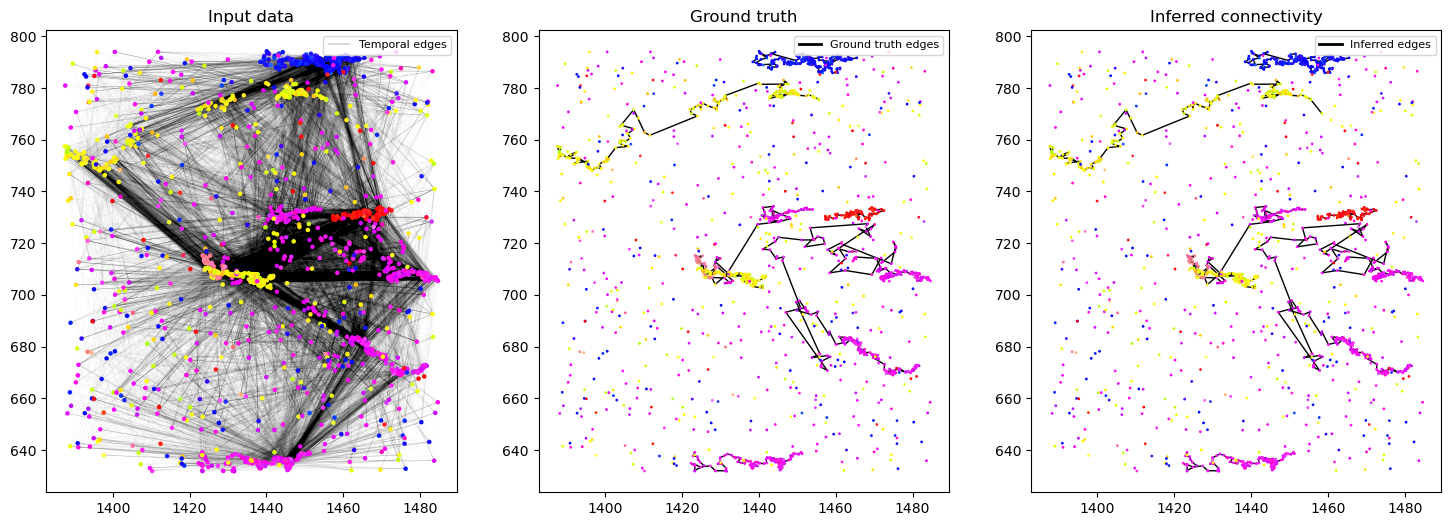

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18,6 ))

edge_index = data_interest.edge_index.cpu().numpy() 
edges = edge_index.T                                    
GT = data_interest.y.cpu().numpy()


color = vertex[:,3:6]/vertex[:,3:6].max(axis=1)[:,np.newaxis]
for i, (u, v) in enumerate(edges):
    x0, y0 = vertex[int(u), 0], vertex[int(u), 1]
    x1, y1 = vertex[int(v), 0], vertex[int(v), 1]
    axes[0].plot([x0, x1], [y0, y1], color="k", linewidth=0.1, alpha = 0.1)

axes[0].scatter(vertex[:,0], vertex[:,1], color = color, s=5, zorder=3)
legend_handles = [Line2D([0],[0], color='k', lw=0.2, label='Temporal edges')]
axes[0].legend(handles=legend_handles, loc='upper right', fontsize=8)
axes[0].set_title("Input data")

edges_GT = edges[GT == 1]

for i, (u, v) in enumerate(edges_GT):
    
    x0, y0 = vertex[int(u), 0], vertex[int(u), 1]
    x1, y1 = vertex[int(v), 0], vertex[int(v), 1]
    axes[1].plot([x0, x1], [y0, y1], color="k",linewidth = 1 )
print(edges_GT.shape)

axes[1].scatter(vertex[:,0], vertex[:,1], color = color, s=1, zorder=3)
legend_handles = [Line2D([0],[0], color='k', lw=2, label='Ground truth edges')]
axes[1].legend(handles=legend_handles, loc='upper right', fontsize=8)
axes[1].set_title("Ground truth")

edges_pred = edges[pred.cpu().numpy() > thres]
for i, (u, v) in enumerate(edges_pred):
    x0, y0 = vertex[int(u), 0], vertex[int(u), 1]
    x1, y1 = vertex[int(v), 0], vertex[int(v), 1]
    axes[2].plot([x0, x1], [y0, y1], color="k", linewidth=1)

axes[2].scatter(vertex[:,0], vertex[:,1], color = color, s=1, zorder=3)
legend_handles = [Line2D([0],[0], color='k', lw=2, label='Inferred edges')]
axes[2].legend(handles=legend_handles, loc='upper right', fontsize=8)
axes[2].set_title("Inferred connectivity")

The above plot shows time projected trajectory data. The colored dots are the vertexes (colored particle) and black lines are edeges.

The input data shows all the possible temporal edges.

Compare the ground truth connectivity and inferred connectivity used by the GNN model.

In [6]:
final_trajectories = tracking_main(vertex, edges_original, number_of_color,  intensity_threshold)

So far we only know the edge connectivity, not the trajectory and the above function will extract the individual trajectories mainly using linear optimization.

For more information, please refer the supplimental information of the paper.

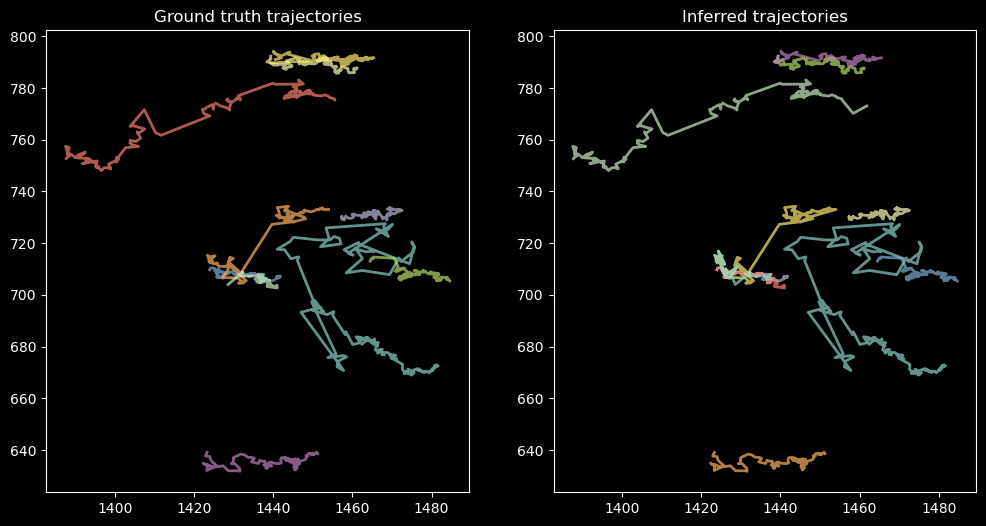

In [ ]:

GT_vertex = GT_merging.x.numpy()
GT_vertex = GT_vertex[GT_vertex[:,number_of_color + 5] != -1]
fig, axes = plt.subplots(1, 2, figsize=(12,6 ))

for i in np.unique(GT_vertex[:,number_of_color + 5]):
    temp = GT_vertex[GT_vertex[:,number_of_color + 5] == i]
    axes[0].plot(temp[:,0], temp[:,1], linewidth=2, alpha=0.7)
    axes[0].set_title("Ground truth trajectories")
    


for i in np.unique(final_trajectories[:,4+ number_of_color]):
    temp = final_trajectories[final_trajectories[:,4+ number_of_color] == i]
    axes[1].plot(temp[:,0], temp[:,1], linewidth=2, alpha=0.7)
    axes[1].set_title("Inferred trajectories")


1400
1500


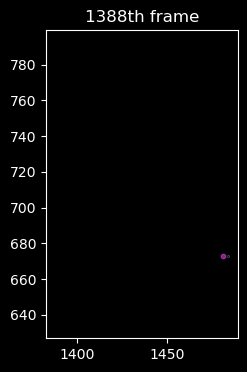

In [8]:
# This will make a time lapse movie of ground truth trajectory

min_x = final_trajectories[:,0].min()
max_x = final_trajectories[:,0].max()
min_y = final_trajectories[:,1].min()
max_y = final_trajectories[:,1].max()



liposome_plot = np.copy(final_trajectories)
liposome_plot = liposome_plot[np.argsort(liposome_plot[:,2])]
marker_size = 5

colors = [(np.random.uniform(0.3, 1.0),np.random.uniform(0.3, 1.0),np.random.uniform(0.3, 1.0)) for i in range(500)]
index = np.unique(liposome_plot[:,4+number_of_color])
index_len = len(index)
color_matrix = pd.DataFrame(np.zeros((1,index_len)))
color_matrix.columns = np.int_(index)
color_matrix.iloc[0] = np.random.choice(range(0,500),index_len )
color_matrix = color_matrix.astype(int)

max_FI = np.array([liposome_plot[:,i+3].max() for i in range(0, number_of_color)])

liposome_plot[:,3:3+number_of_color] = (liposome_plot[:,3:3+number_of_color] / max_FI) ** 0.3
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(4,4))
ax.set_aspect('equal')


def animate(i):
    if i%100 == 0:
        print(i)
    ax.clear()
    ax.set_xlim([min_x-5, max_x + 5])
    ax.set_ylim([min_y-5, max_y + 5])
    temp_dot = vertex[vertex[:,2] == i]

    if len(temp_dot) > 0:
        max_FI = np.array([temp_dot[:,3:3+number_of_color].max() for i in range(0, number_of_color)])
        temp_dot[:,3:3+number_of_color] = (temp_dot[:,3:3+number_of_color] / max_FI) ** 0.3
    temp_current = liposome_plot[liposome_plot[:,2] == i]
    temp_dot_color = temp_dot[:,3:3+number_of_color]

    temp_dot_color = np.column_stack((temp_dot_color,temp_dot_color,temp_dot_color,temp_dot_color))
    temp_dot_color = temp_dot_color[:,:3]
    ax.scatter(temp_dot[:,0], temp_dot[:,1],
                c = temp_dot_color, 
                marker = ".", 
                s = 40,
                alpha= 0.5,
                edgecolor = None)

    temp_line = liposome_plot[(liposome_plot[:,2] <= i) &(liposome_plot[:,2] > i - 8) ]
    temp_line_unique = np.unique(temp_current[:,4+number_of_color])
    xy_memory = np.zeros((1,2))

    for index_liposome in temp_line_unique:
        temp_line_plot = temp_line[temp_line[:,4+number_of_color] == index_liposome]
        xy_original = np.array([temp_line_plot[:,0][-1], temp_line_plot[:,1][-1]])
        text_spacing = len(xy_memory[(xy_memory == xy_original).all(axis=1)])*2

        ax.plot(temp_line_plot[:,0], temp_line_plot[:,1], color = np.array(colors[color_matrix[index_liposome][0]]) , alpha = 0.5 , linewidth = 0.6)

        ax.annotate(str(int(index_liposome)), xy = (temp_line_plot[-1,0] + 2,temp_line_plot[-1,1] +text_spacing-1), color = np.array(colors[color_matrix[index_liposome][0]]) , size =3, alpha = 0.4,fontweight='bold')
        xy_memory = np.vstack((xy_memory, xy_original))
    ax.set_title(str(int(i)) +"th frame")

ani = FuncAnimation(fig, animate,frames= [i for i in range(final_trajectories[:,2].min().astype(int), final_trajectories[:,2].max().astype(int) + 1)], blit = False)

ani.save('Track_GT_line.avi', fps=3,dpi=300, extra_args=['-vcodec', 'mjpeg'], bitrate = 7000)


1400
1500


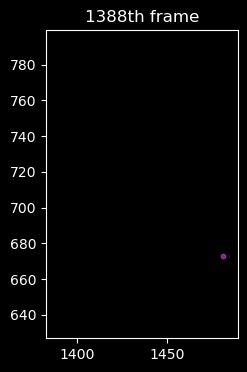

In [9]:
# This will make a time lapse movie of  inferred trajectory

liposome_plot = np.copy(final_trajectories)
liposome_plot = liposome_plot[np.argsort(liposome_plot[:,2])]
marker_size = 5

colors = [(np.random.uniform(0.3, 1.0),np.random.uniform(0.3, 1.0),np.random.uniform(0.3, 1.0)) for i in range(500)]
index = np.unique(liposome_plot[:,4+number_of_color])
index_len = len(index)
color_matrix = pd.DataFrame(np.zeros((1,index_len)))
color_matrix.columns = np.int_(index)
color_matrix.iloc[0] = np.random.choice(range(0,500),index_len )
color_matrix = color_matrix.astype(int)

max_FI = np.array([liposome_plot[:,i+3].max() for i in range(0, number_of_color)])

liposome_plot[:,3:3+number_of_color] = (liposome_plot[:,3:3+number_of_color] / max_FI) ** 0.3
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(4,4))
ax.set_aspect('equal')


def animate(i):
    if i%100 == 0:
        print(i)
    ax.clear()
    ax.set_xlim([min_x-5, max_x + 5])
    ax.set_ylim([min_y-5, max_y + 5])
    temp_dot = vertex[vertex[:,2] == i]

    if len(temp_dot) > 0:
        max_FI = np.array([temp_dot[:,3:3+number_of_color].max() for i in range(0, number_of_color)])
        temp_dot[:,3:3+number_of_color] = (temp_dot[:,3:3+number_of_color] / max_FI) ** 0.3
    temp_current = liposome_plot[liposome_plot[:,2] == i]
    temp_dot_color = temp_dot[:,3:3+number_of_color]

    temp_dot_color = np.column_stack((temp_dot_color,temp_dot_color,temp_dot_color,temp_dot_color))
    temp_dot_color = temp_dot_color[:,:3]
    ax.scatter(temp_dot[:,0], temp_dot[:,1],
                c = temp_dot_color, 
                marker = ".", 
                s = 40,
                alpha= 0.5,
                edgecolor = None)

    temp_line = liposome_plot[(liposome_plot[:,2] <= i) &(liposome_plot[:,2] > i - 8) ]
    temp_line_unique = np.unique(temp_current[:,4+number_of_color])
    xy_memory = np.zeros((1,2))

    for index_liposome in temp_line_unique:
        temp_line_plot = temp_line[temp_line[:,4+number_of_color] == index_liposome]
        xy_original = np.array([temp_line_plot[:,0][-1], temp_line_plot[:,1][-1]])
        text_spacing = len(xy_memory[(xy_memory == xy_original).all(axis=1)])*2

        ax.plot(temp_line_plot[:,0], temp_line_plot[:,1], color = np.array(colors[color_matrix[index_liposome][0]]) , alpha = 0.5 , linewidth = 0.6)

        ax.annotate(str(int(index_liposome)), xy = (temp_line_plot[-1,0] + 2,temp_line_plot[-1,1] +text_spacing-1), color = np.array(colors[color_matrix[index_liposome][0]]) , size =3, alpha = 0.4,fontweight='bold')
        xy_memory = np.vstack((xy_memory, xy_original))
    ax.set_title(str(int(i)) +"th frame")

frames = range(int(liposome_plot[:,2].min()), int(liposome_plot[:,2].max())+1)
ani = FuncAnimation(fig, animate, frames=frames, blit=False)
ani.save('Track_GNN_line.avi', fps=3,dpi=300, extra_args=['-vcodec', 'mjpeg'], bitrate = 7000)